# Méthode 1 — Détection de la cataracte par HOG + SVM
**Mini Projet — Vidéo Biomédicale · Master BIAM 2025/2026**

| | |
|---|---|
| **Dataset** | cataract-eye-detection v2 (Roboflow) |
| **Classes** | 0 = sain · 1 = cataracte |
| **Méthode** | HOG + LinearSVC |
| **Environnement** | Kaggle Notebook |

### Pipeline
```
Roboflow API → Images + Labels YOLO
      ↓
Extraction patches (bbox → crop)
      ↓
Descripteurs HOG (1764 valeurs/patch)
      ↓
StandardScaler + LinearSVC
      ↓
Évaluation : Accuracy · Précision · Rappel · F1 · Confusion matrix
```

---
## Cellule 1 — Installation des dépendances

In [1]:
!pip install roboflow -q
!pip install scikit-image -q

print('Installation terminée.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
Installation terminée.


---
## Cellule 2 — Téléchargement du dataset via Roboflow

In [2]:
# ── Option A : API key dans les Secrets Kaggle (recommandé) ─────────────────
# Pour configurer : Kaggle → onglet Add-ons → Secrets → ajouter ROBOFLOW_API_KEY
try:
    from kaggle_secrets import UserSecretsClient
    api_key = UserSecretsClient().get_secret('ROBOFLOW_API_KEY')
    print('Clé API chargée depuis les Secrets Kaggle.')
except Exception:
    # ── Option B : clé directe (si pas de Secrets configurés) ───────────────
    api_key = 'COLLE_TON_API_KEY_ICI'
    print('Clé API chargée depuis le code (pense à configurer les Secrets).')

# ── Téléchargement ───────────────────────────────────────────────────────────
from roboflow import Roboflow

rf      = Roboflow(api_key=api_key)
project = rf.workspace('jaouads-workspace').project('cataract-eye-detection')
version = project.version(4)
dataset = version.download('yolov5')

print(f'\nDataset téléchargé dans : {dataset.location}')

Clé API chargée depuis les Secrets Kaggle.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cataract-eye-detection-4 in yolov5pytorch:: 100%|██████████| 9463/9463 [00:00<00:00, 10805.94it/s]



Dataset téléchargé dans : /kaggle/working/cataract-eye-detection-4


---
## Cellule 3 — Imports et configuration des chemins

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score)
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# ── Chemins (basés sur dataset.location fourni par Roboflow) ─────────────────
BASE_DIR  = Path(dataset.location)

TRAIN_IMG = BASE_DIR / 'train' / 'images'
TRAIN_LBL = BASE_DIR / 'train' / 'labels'
VALID_IMG = BASE_DIR / 'valid' / 'images'
VALID_LBL = BASE_DIR / 'valid' / 'labels'
TEST_IMG  = BASE_DIR / 'test'  / 'images'
TEST_LBL  = BASE_DIR / 'test'  / 'labels'

# ── Paramètres globaux ───────────────────────────────────────────────────────
PATCH_SIZE  = (64, 128)           # taille de redimensionnement du patch
CLASS_NAMES = ['sain', 'cataracte']  # v4: class 0=sain, 1=cataracte (verified visually)

# ── Vérification des dossiers ────────────────────────────────────────────────
print(f'BASE_DIR : {BASE_DIR}\n')
for split, img_dir in [('train', TRAIN_IMG), ('valid', VALID_IMG), ('test', TEST_IMG)]:
    n_jpg = len(list(img_dir.glob('*.jpg')))
    n_png = len(list(img_dir.glob('*.png')))
    print(f'  {split:5s} : {n_jpg + n_png} images  ({img_dir})')

BASE_DIR : /kaggle/working/cataract-eye-detection-4

  train : 4135 images  (/kaggle/working/cataract-eye-detection-4/train/images)
  valid : 396 images  (/kaggle/working/cataract-eye-detection-4/valid/images)
  test  : 198 images  (/kaggle/working/cataract-eye-detection-4/test/images)


---
## Cellule 4 — Chargement des patches depuis les annotations YOLO

In [4]:
def load_patches_and_labels(img_dir, lbl_dir, patch_size=PATCH_SIZE):
    """
    Lit chaque image + son fichier .txt d'annotation YOLO.
    Extrait le patch oculaire correspondant à la bounding box.

    Format annotation YOLO (normalisé 0-1) :
      class_id  x_center  y_center  width  height

    Retourne :
      patches : array (N, H, W) en niveaux de gris
      labels  : array (N,) avec 0=sain, 1=cataracte
    """
    patches, labels = [], []
    img_paths = sorted(Path(img_dir).glob('*.jpg')) + \
                sorted(Path(img_dir).glob('*.png'))

    for img_path in img_paths:
        lbl_path = Path(lbl_dir) / (img_path.stem + '.txt')
        if not lbl_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])

                # Coordonnées YOLO normalisées → pixels
                x1 = max(0, int((xc - bw / 2) * w))
                y1 = max(0, int((yc - bh / 2) * h))
                x2 = min(w, int((xc + bw / 2) * w))
                y2 = min(h, int((yc + bh / 2) * h))

                patch = img[y1:y2, x1:x2]
                if patch.size == 0:
                    continue

                # Niveaux de gris + redimensionnement uniforme
                patch_gray    = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
                patch_resized = cv2.resize(patch_gray, patch_size)

                patches.append(patch_resized)
                labels.append(cls_id)

    return np.array(patches), np.array(labels)


print('Chargement des patches...')
t0 = time.time()

X_train_raw, y_train = load_patches_and_labels(TRAIN_IMG, TRAIN_LBL)
X_val_raw,   y_val   = load_patches_and_labels(VALID_IMG, VALID_LBL)
X_test_raw,  y_test  = load_patches_and_labels(TEST_IMG,  TEST_LBL)

print(f'Chargement terminé en {time.time()-t0:.1f}s\n')
print(f"{'Split':8s} {'Total':>7s} {'Sain':>7s} {'Cataracte':>10s}")
print('-' * 36)
for name, y in [('train', y_train), ('valid', y_val), ('test', y_test)]:
    print(f"{name:8s} {len(y):>7d} {np.sum(y==0):>7d} {np.sum(y==1):>10d}")

Chargement des patches...
Chargement terminé en 8.4s

Split      Total    Sain  Cataracte
------------------------------------
train       4144    3252        892
valid        398     314         84
test         198     163         35


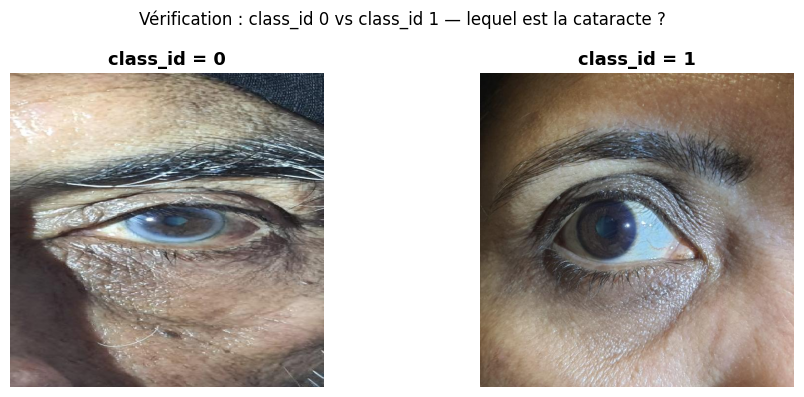

In [5]:
# Vérification : ouvrir quelques .txt et regarder quel class_id
# correspond visuellement aux yeux malades vs sains

from pathlib import Path
import cv2, matplotlib.pyplot as plt

img_dir = Path(BASE_DIR) / 'train' / 'images'
lbl_dir = Path(BASE_DIR) / 'train' / 'labels'

# Trouver une image avec class_id = 0 et une avec class_id = 1
exemples = {0: None, 1: None}

for lbl_path in sorted(lbl_dir.glob('*.txt')):
    with open(lbl_path) as f:
        for line in f:
            cls_id = int(line.strip().split()[0])
            if exemples[cls_id] is None:
                img_path = img_dir / (lbl_path.stem + '.jpg')
                if img_path.exists():
                    exemples[cls_id] = (img_path, lbl_path)
    if all(v is not None for v in exemples.values()):
        break

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Vérification : class_id 0 vs class_id 1 — lequel est la cataracte ?')

for cls_id, (img_path, lbl_path) in exemples.items():
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    axes[cls_id].imshow(img)
    axes[cls_id].set_title(f'class_id = {cls_id}', fontsize=13, fontweight='bold')
    axes[cls_id].axis('off')

plt.tight_layout()
plt.show()
# → Regarde quelle image est la cataracte (œil trouble/blanc)
# → Si class_id=0 est la cataracte → names = ['cataracte', 'sain']
# → Si class_id=1 est la cataracte → names = ['sain', 'cataracte']  (original)

---
## Cellule 5 — Visualisation des patches extraits

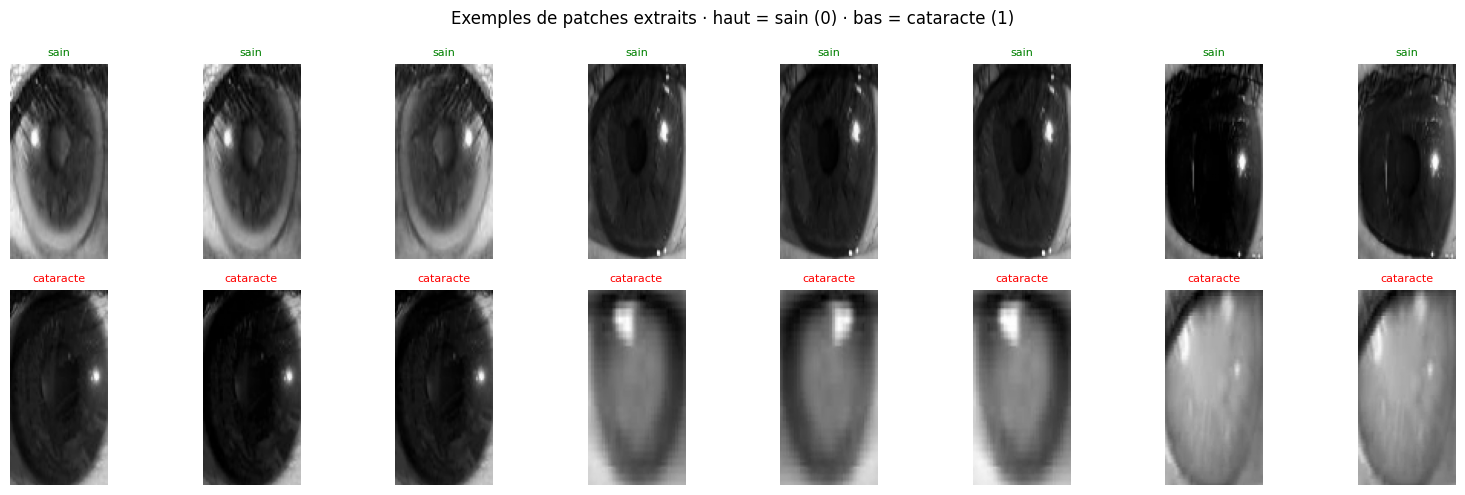

Figure sauvegardée : patches_visualisation.png


In [6]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Exemples de patches extraits · haut = sain (0) · bas = cataracte (1)',
             fontsize=12)

sain_idx      = np.where(y_train == 0)[0][:8]
cataracte_idx = np.where(y_train == 1)[0][:8]

for i, idx in enumerate(sain_idx):
    axes[0, i].imshow(X_train_raw[idx], cmap='gray')
    axes[0, i].set_title('sain', fontsize=8, color='green')
    axes[0, i].axis('off')

for i, idx in enumerate(cataracte_idx):
    axes[1, i].imshow(X_train_raw[idx], cmap='gray')
    axes[1, i].set_title('cataracte', fontsize=8, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('patches_visualisation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : patches_visualisation.png')

---
## Cellule 6 — Extraction des descripteurs HOG

In [7]:
def build_hog_descriptor(patch_size=PATCH_SIZE):
    """
    Crée le descripteur HOG OpenCV.

    Paramètres (adaptés au patch 64×64) :
      winSize     = 64×64   taille de la fenêtre d'analyse
      blockSize   = 16×16   taille d'un bloc (4 cellules)
      blockStride = 8×8     chevauchement des blocs (50%)
      cellSize    = 8×8     taille d'une cellule
      nbins       = 9       orientations de gradients (0°–180°)

    Taille du vecteur résultant :
      blocs en X = (64-16)/8 + 1 = 7
      blocs en Y = (64-16)/8 + 1 = 7
      vecteur    = 7 × 7 × 4 cellules × 9 bins = 1764 valeurs
    """
    return cv2.HOGDescriptor(
        _winSize    = patch_size,
        _blockSize  = (16, 16),
        _blockStride= (8, 8),
        _cellSize   = (8, 8),
        _nbins      = 9
    )


def extract_hog_features(patches, hog):
    """Applique le descripteur HOG sur un tableau de patches."""
    features = []
    for patch in patches:
        desc = hog.compute(patch)       # shape (N, 1)
        features.append(desc.flatten())
    return np.array(features)


hog_descriptor = build_hog_descriptor()

print('Extraction HOG...')
t0 = time.time()

X_train_hog = extract_hog_features(X_train_raw, hog_descriptor)
X_val_hog   = extract_hog_features(X_val_raw,   hog_descriptor)
X_test_hog  = extract_hog_features(X_test_raw,  hog_descriptor)

print(f'Extraction terminée en {time.time()-t0:.1f}s')
print(f'Taille vecteur HOG : {X_train_hog.shape[1]} valeurs')
print(f'Shape train  : {X_train_hog.shape}')
print(f'Shape valid  : {X_val_hog.shape}')
print(f'Shape test   : {X_test_hog.shape}')

Extraction HOG...
Extraction terminée en 1.0s
Taille vecteur HOG : 3780 valeurs
Shape train  : (4144, 3780)
Shape valid  : (398, 3780)
Shape test   : (198, 3780)


---
## Cellule 7 — Visualisation HOG : patch original vs descripteur

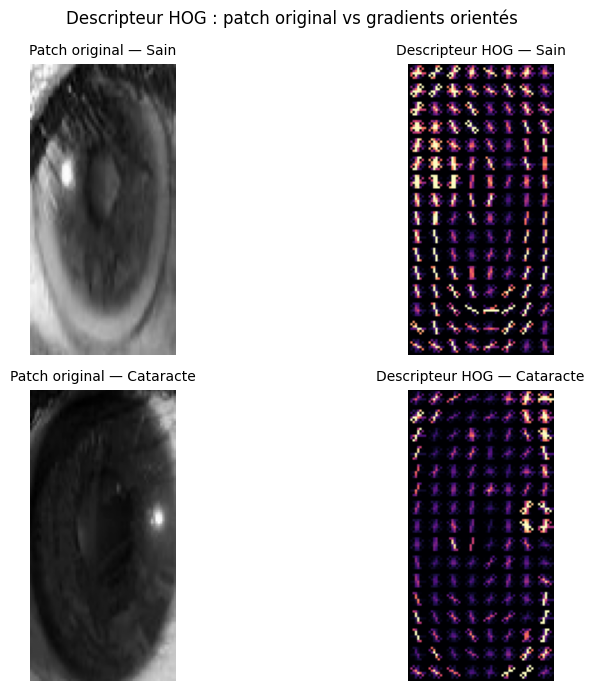

Figure sauvegardée : hog_visualisation.png


In [8]:
from skimage.feature import hog as sk_hog
from skimage import exposure

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Descripteur HOG : patch original vs gradients orientés', fontsize=12)

for row, (cls, label) in enumerate([(0, 'Sain'), (1, 'Cataracte')]):
    idx   = np.where(y_train == cls)[0][0]
    patch = X_train_raw[idx]

    fd, hog_img = sk_hog(
        patch,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True
    )
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[row, 0].imshow(patch, cmap='gray')
    axes[row, 0].set_title(f'Patch original — {label}', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(hog_img_rescaled, cmap='magma')
    axes[row, 1].set_title(f'Descripteur HOG — {label}', fontsize=10)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig('hog_visualisation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : hog_visualisation.png')

---
## Cellule 8 — Entraînement du SVM

In [9]:
# Pipeline scikit-learn : StandardScaler + LinearSVC
#
# StandardScaler : centre (moyenne=0) et réduit (écart-type=1) chaque feature
#   → indispensable pour SVM (très sensible à l'échelle des features)
#
# LinearSVC (C=1.0) : classifieur à vecteurs de support linéaire
#   → C contrôle le compromis biais/variance :
#     petit C → marges larges, plus robuste mais moins précis
#     grand C → marges étroites, plus précis mais risque de surapprentissage

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    LinearSVC(C=1.0, max_iter=3000, random_state=42))
])

print('Entraînement SVM...')
t_train_start = time.time()
pipeline.fit(X_train_hog, y_train)
train_time = time.time() - t_train_start

# Score rapide sur validation
val_acc = pipeline.score(X_val_hog, y_val)

print(f'Entraînement terminé en {train_time:.2f}s')
print(f'Accuracy validation    : {val_acc*100:.2f}%')

# Sauvegarde du modèle
joblib.dump(pipeline, 'hog_svm_cataract.pkl')
print('Modèle sauvegardé      : hog_svm_cataract.pkl')

Entraînement SVM...
Entraînement terminé en 5.25s
Accuracy validation    : 90.45%
Modèle sauvegardé      : hog_svm_cataract.pkl


---
## Cellule 9 — Évaluation complète sur le jeu de test

In [10]:
print('=== Évaluation sur le jeu de TEST ===')

t_infer_start = time.time()
y_pred        = pipeline.predict(X_test_hog)
infer_time    = time.time() - t_infer_start

# Rapport détaillé par classe
print('\nRapport de classification :')
print(classification_report(y_test, y_pred,
                             target_names=CLASS_NAMES,
                             digits=4))

# Métriques globales
acc_test      = pipeline.score(X_test_hog, y_test)
precision     = precision_score(y_test, y_pred, average='weighted')
recall        = recall_score(y_test, y_pred, average='weighted')
f1_macro      = f1_score(y_test, y_pred, average='macro')
f1_weighted   = f1_score(y_test, y_pred, average='weighted')
ms_per_img    = infer_time / len(X_test_hog) * 1000

# Stocker pour la comparaison finale avec YOLO
results_hog_svm = {
    'accuracy'   : acc_test,
    'precision'  : precision,
    'recall'     : recall,
    'f1_macro'   : f1_macro,
    'f1_weighted': f1_weighted,
    'train_time' : train_time,
    'ms_per_img' : ms_per_img
}
print(f'Accuracy test    : {acc_test*100:.2f}%')
print(f'Précision        : {precision*100:.2f}%')
print(f'Rappel           : {recall*100:.2f}%')
print(f'F1 weighted      : {f1_weighted:.4f}')
print(f'F1 macro         : {f1_macro:.4f}')
print(f'Temps entraînem. : {train_time:.2f}s')
print(f'Inférence/image  : {ms_per_img:.2f} ms')

=== Évaluation sur le jeu de TEST ===

Rapport de classification :
              precision    recall  f1-score   support

   cataracte     0.9387    0.9387    0.9387       163
        sain     0.7143    0.7143    0.7143        35

    accuracy                         0.8990       198
   macro avg     0.8265    0.8265    0.8265       198
weighted avg     0.8990    0.8990    0.8990       198

Accuracy test    : 89.90%
Précision        : 89.90%
Rappel           : 89.90%
F1 weighted      : 0.8990
F1 macro         : 0.8265
Temps entraînem. : 5.25s
Inférence/image  : 0.05 ms


---
## Cellule 10 — Matrice de confusion

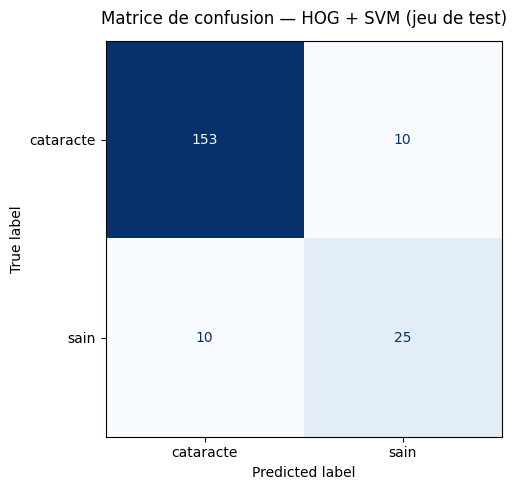

Figure sauvegardée : confusion_matrix_hog_svm.png

Vrais Négatifs  (TN) :  153  → œils sains correctement classés
Faux Positifs   (FP) :   10  → sains classés cataracte (fausse alarme)
Faux Négatifs   (FN) :   10  → cataractes manquées ⚠ (risque clinique)
Vrais Positifs  (TP) :   25  → cataractes correctement détectées

Sensibilité (recall cataracte) : 71.43%
Spécificité (recall sain)      : 93.87%


In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — HOG + SVM (jeu de test)', fontsize=12, pad=12)

plt.tight_layout()
plt.savefig('confusion_matrix_hog_svm.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : confusion_matrix_hog_svm.png')

# Interprétation clinique
tn, fp, fn, tp = cm.ravel()
print(f'\nVrais Négatifs  (TN) : {tn:4d}  → œils sains correctement classés')
print(f'Faux Positifs   (FP) : {fp:4d}  → sains classés cataracte (fausse alarme)')
print(f'Faux Négatifs   (FN) : {fn:4d}  → cataractes manquées ⚠ (risque clinique)')
print(f'Vrais Positifs  (TP) : {tp:4d}  → cataractes correctement détectées')

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f'\nSensibilité (recall cataracte) : {sensitivity*100:.2f}%')
print(f'Spécificité (recall sain)      : {specificity*100:.2f}%')

---
## Cellule 11 — Visualisation des détections sur images test

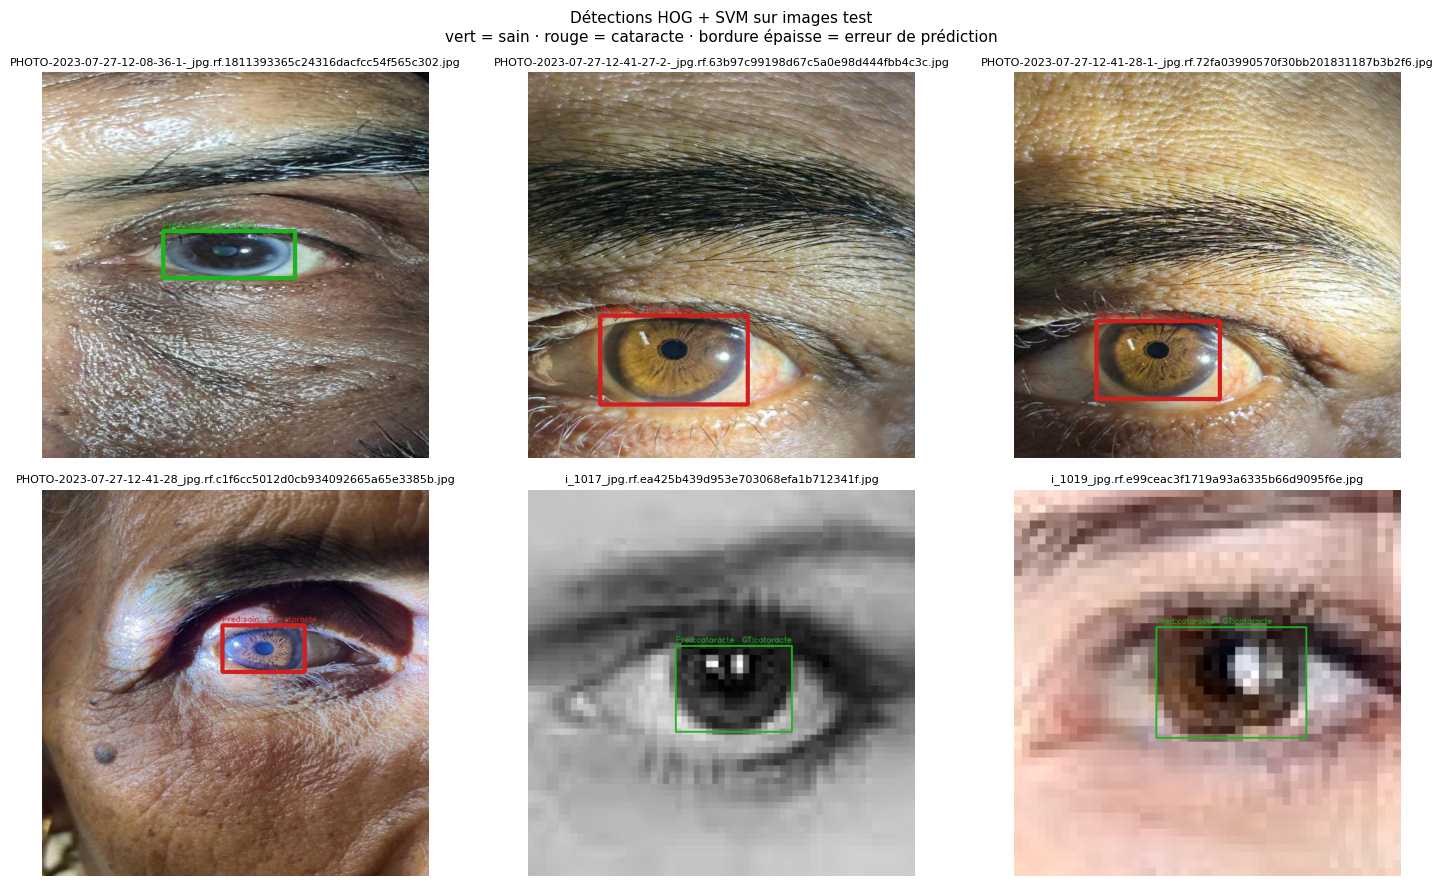

Figure sauvegardée : detections_hog_svm.png


In [12]:
def detect_and_draw(img_path, lbl_path, pipeline, patch_size=PATCH_SIZE):
    """
    Lit l'image, extrait les patches via bbox YOLO,
    prédit avec HOG+SVM et dessine le résultat.

    Couleurs :
      vert   = prédit sain
      rouge  = prédit cataracte
      trait épais = prédiction incorrecte (erreur)
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result  = img_rgb.copy()
    h, w    = img.shape[:2]

    if not Path(lbl_path).exists():
        return result

    hog = build_hog_descriptor(patch_size)

    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            gt_cls = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])

            x1 = max(0, int((xc - bw/2) * w))
            y1 = max(0, int((yc - bh/2) * h))
            x2 = min(w, int((xc + bw/2) * w))
            y2 = min(h, int((yc + bh/2) * h))

            patch = img[y1:y2, x1:x2]
            if patch.size == 0:
                continue

            patch_g = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
            patch_r = cv2.resize(patch_g, patch_size)
            feat    = hog.compute(patch_r).flatten().reshape(1, -1)
            pred    = pipeline.predict(feat)[0]

            correct   = (pred == gt_cls)
            color     = (30, 180, 30) if pred == 0 else (210, 30, 30)
            thickness = 2 if correct else 5

            cv2.rectangle(result, (x1, y1), (x2, y2), color, thickness)

            label_str = f"Pred:{CLASS_NAMES[pred]}  GT:{CLASS_NAMES[gt_cls]}"
            cv2.putText(result, label_str, (x1, max(y1 - 6, 14)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)

    return result


# Récupérer 6 images test
test_imgs = sorted(Path(TEST_IMG).glob('*.jpg'))[:6]
if not test_imgs:
    test_imgs = sorted(Path(TEST_IMG).glob('*.png'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    'Détections HOG + SVM sur images test\n'
    'vert = sain · rouge = cataracte · bordure épaisse = erreur de prédiction',
    fontsize=11
)

for ax, img_path in zip(axes.flatten(), test_imgs):
    lbl_path = Path(TEST_LBL) / (img_path.stem + '.txt')
    result   = detect_and_draw(img_path, lbl_path, pipeline)
    if result is not None:
        ax.imshow(result)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('detections_hog_svm.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : detections_hog_svm.png')

---
## Cellule 12 — Résumé final des performances

In [13]:
print('=' * 56)
print('    RÉSUMÉ — Méthode 1 : HOG + SVM')
print('    Dataset : cataract-eye-detection v2 (Roboflow)')
print('=' * 56)
print(f'  Patch size         : {PATCH_SIZE}')
print(f'  Vecteur HOG        : {X_train_hog.shape[1]} valeurs')
print(f'  Données train      : {len(X_train_hog)} patches')
print(f'  Données test       : {len(X_test_hog)} patches')
print('-' * 56)
print(f'  Accuracy           : {results_hog_svm["accuracy"]*100:.2f}%')
print(f'  Précision weighted : {results_hog_svm["precision"]*100:.2f}%')
print(f'  Rappel weighted    : {results_hog_svm["recall"]*100:.2f}%')
print(f'  F1 weighted        : {results_hog_svm["f1_weighted"]:.4f}')
print(f'  F1 macro           : {results_hog_svm["f1_macro"]:.4f}')
print(f'  Sensibilité        : {sensitivity*100:.2f}%')
print(f'  Spécificité        : {specificity*100:.2f}%')
print('-' * 56)
print(f'  Temps entraînem.   : {results_hog_svm["train_time"]:.2f}s')
print(f'  Inférence/image    : {results_hog_svm["ms_per_img"]:.2f} ms')
print('=' * 56)
print('\n→ Ces valeurs seront comparées avec YOLO (Méthode 2).')
print('→ Fichiers générés :')
print('   - hog_svm_cataract.pkl        (modèle sauvegardé)')
print('   - patches_visualisation.png')
print('   - hog_visualisation.png')
print('   - confusion_matrix_hog_svm.png')
print('   - detections_hog_svm.png')

    RÉSUMÉ — Méthode 1 : HOG + SVM
    Dataset : cataract-eye-detection v2 (Roboflow)
  Patch size         : (64, 128)
  Vecteur HOG        : 3780 valeurs
  Données train      : 4144 patches
  Données test       : 198 patches
--------------------------------------------------------
  Accuracy           : 89.90%
  Précision weighted : 89.90%
  Rappel weighted    : 89.90%
  F1 weighted        : 0.8990
  F1 macro           : 0.8265
  Sensibilité        : 71.43%
  Spécificité        : 93.87%
--------------------------------------------------------
  Temps entraînem.   : 5.25s
  Inférence/image    : 0.05 ms

→ Ces valeurs seront comparées avec YOLO (Méthode 2).
→ Fichiers générés :
   - hog_svm_cataract.pkl        (modèle sauvegardé)
   - patches_visualisation.png
   - hog_visualisation.png
   - confusion_matrix_hog_svm.png
   - detections_hog_svm.png
